In [ ]:
import torch
import nni 
import torch.nn as nn
import torch.optim as optim
from nni import get_next_parameter
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import recall_score, auc, roc_curve, confusion_matrix, f1_score, accuracy_score
import numpy as np
import pandas as pd
import joblib
from scipy.io import loadmat
import matplotlib.pyplot as plt
from ptflops import get_model_complexity_info
from collections import Counter

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

Device in use: cuda


In [3]:
def read_data(data_path):
    pd0=pd.read_csv(data_path+"/MLData2022.csv", sep=',')
    pd1=pd.read_csv(data_path+"/evalRuns.csv", sep=',')
    pd2=pd.read_csv(data_path+"/testRuns.csv", sep=',')

    pd1['classify_ae']=np.ones(pd1.shape[0])
    pd1['anomaly_new']=np.ones(pd1.shape[0])
    pd1['anomaly_new_adapt']=np.ones(pd1.shape[0])

    pd2['classify_ae']=np.zeros(pd2.shape[0])
    pd2['anomaly_new']=np.zeros(pd2.shape[0])
    pd2['anomaly_new_adapt']=np.zeros(pd2.shape[0])
    
    dist_q=np.array(pd2[['D_euc_vec_1', 'D_euc_vec_2', 'D_dtw_vec_1', 'D_dtw_vec_2']])
    dist_nq=np.array(pd1[['D_euc_vec_1', 'D_euc_vec_2', 'D_dtw_vec_1', 'D_dtw_vec_2']])
    dist_2022=np.array(pd0[['Var6_1', 'Var6_2', 'Var7_1', 'Var7_2']])
    print(dist_nq.shape)
    
    id=dist_nq[:, 0]!=0
    dist_nq=dist_nq[id, :]
    print(dist_nq.shape)
    
    gt_q=np.array(pd2['classify_ae'])
    gt_nq=np.array(pd1['classify_ae'])[id]
    print(gt_nq.shape)
    gt_2022=np.array(pd0[['Var8']])

    train =np.concatenate([dist_q, dist_nq, dist_2022[0:100000, :]], axis=0)
    test=dist_2022[100000:, :]

    gt_2022=gt_2022.reshape(gt_2022.shape[0],)
    print(f"{gt_q.shape}, {gt_nq.shape}, {gt_2022.shape}")
    gt_2022[gt_2022!=0]=1

    gt_train=np.concatenate([gt_q, gt_nq, gt_2022[0:100000]], axis=0)
    gt_test=gt_2022[100000:]

    Ytrain = 1 - gt_train[:]
    Ytest = 1 - gt_test[:]  

    print(f" train description : {pd.Categorical(Ytrain).describe()}")
    # Ytrain_tensor = torch.tensor(Ytrain, dtype=torch.long)
    # Y_train = torch.nn.functional.one_hot(Ytrain_tensor, num_classes=2).float()

    print(f" test description {pd.Categorical(Ytest).describe()}")
    # Ytest_tensor = torch.tensor(Ytest, dtype=torch.long) 
    # Y_test = torch.nn.functional.one_hot(Ytest_tensor, num_classes=2).float()

    return train, test, Ytrain, Ytest

In [ ]:
def print_class_proportions(loader, loader_name="DataLoader"):
    all_labels = []

    for _, labels in loader:

        all_labels.extend(labels.view(-1).cpu().numpy())
    
    label_counts = Counter(all_labels)
    
    total = len(all_labels)
    class_proportions = {class_label: count / total for class_label, count in label_counts.items()}

    print(f"--- {loader_name} Class Counts and Proportions ---")
    for class_label, count in label_counts.items():
        proportion = class_proportions[class_label]
        print(f"Class {class_label}: Count = {count}, Proportion = {proportion * 100:.2f}%")
    print()

# # Print class counts and proportions for train, test, and validation loaders
# print_class_proportions(train_loader, "Train Loader")
# print_class_proportions(test_loader, "Test Loader")
# print_class_proportions(val_loader, "Validation Loader")


In [ ]:
def inference_on_test(model, test_loader):
    model.eval()
    with torch.no_grad():
        all_preds = []
        all_labels = []
        
        for inputs, labels in test_loader:
            # print(type(inputs))
            # print(type(labels))
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).squeeze()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(probs.cpu().numpy())

    # print(len(all_labels))
    # print(len(all_preds))
    all_preds_binary = [1 if p > 0.5 else 0 for p in all_preds]
    
    auc = roc_auc_score(all_labels, all_preds_binary)
    accuracy = accuracy_score(all_labels, all_preds_binary)
    precision = precision_score(all_labels, all_preds_binary, zero_division=0)
    recall = recall_score(all_labels, all_preds_binary)
    f1 = f1_score(all_labels, all_preds_binary)

    print("*********** Results of inference on test ********")
    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # print(torch.cuda.memory_allocated())  
    # print(torch.cuda.memory_reserved()) 

    metrics = {
        'AUC': auc,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }
    
    return auc, all_preds_binary, all_labels

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_layer_1_neurons, hidden_layer_2_neurons, hidden_layer_3_neurons, output_size):
        super(MLP, self).__init__()
        layers = []
        layers.append(nn.Linear(input_size, hidden_layer_1_neurons))
        layers.append(nn.ReLU())
        
        if hidden_layer_2_neurons > 0:
            layers.append(nn.Linear(hidden_layer_1_neurons, hidden_layer_2_neurons))
            layers.append(nn.ReLU())
            previous_neurons = hidden_layer_2_neurons
        else:
            previous_neurons = hidden_layer_1_neurons

        if hidden_layer_3_neurons > 0:
            layers.append(nn.Linear(previous_neurons, hidden_layer_3_neurons))
            layers.append(nn.ReLU())
            previous_neurons = hidden_layer_3_neurons

        layers.append(nn.Linear(previous_neurons, output_size))

        self.model = nn.Sequential(*layers)

        self.model.apply(self._initialize_weights)
        
    def _initialize_weights(self, layer):
            """Initialize weights and biases for Linear layers."""
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.model(x)

In [ ]:
def std_normalize(train_array, save_factors_path):
    mean = np.mean(train_array, axis=0)
    std = np.std(train_array, axis=0)
    
    print(f"Mean: {mean}")
    print(f"STD: {std}")
    std[std == 0] = 1
    normalized_array = (train_array - mean) / std
    
    return normalized_array, mean, std


def normalize_test_array(test_array, use_standardization, fac1, fac2, load_factors_path):
    if not use_standardization:
        max_vals = fac1
        min_vals = fac2
        normalized_array = (test_array - min_vals) / (max_vals - min_vals)
    else:
        mean_vals = fac1
        std_vals = fac2
        std_vals[std_vals == 0] = 1
        normalized_array = (test_array - mean_vals) / std_vals
    
    return normalized_array

In [9]:
data_path="/data/dust/user/boukela/code/Pcode_dev/Data"
#read data
Xtrain, Xtest, Ytrain, Ytest =read_data(data_path)
distance_type='euc'    
if distance_type=='euc':
    train_x=Xtrain[:, 0:2]
    test_x=Xtest[:, 0:2]
elif distance_type=='dtw':
    train_x=Xtrain[:, 2:]
    test_x=Xtest[:, 2:]
elif distance_type=='both':
    train_x=Xtrain
    test_x=Xtest
else:
    print("distance incorrect")

print("\n ***** Normalization ***** \n")
train_x_norm, means, stds = std_normalize(train_x, 'normalization_factors.pkl')

(407, 4)
(341, 4)
(341,)
(67,), (341,), (146403,)
 train description :             counts     freqs
categories                  
0.0         100085  0.996783
1.0            323  0.003217
 test description             counts     freqs
categories                  
0            46331  0.998448
1               72  0.001552

 ***** Normalization ***** 

Mean: [21.53148511 16.47764607]
STD: [19.88790257  9.85630508]


In [28]:
input_size = 2
output_size = 1
best_trial_params= {
"input_size":2,
"hidden_layer_1_neurons": 49,
"hidden_layer_2_neurons": 100,
"hidden_layer_3_neurons": 36,
"output_size": 1
}

model_dict = joblib.load(f"nni/models/model_2tf9osk5_aquSV.joblib")
# print(model_dict)
model = MLP(**best_trial_params)
model.load_state_dict(model_dict)
model = model.to(device) 

In [29]:
# to load in the future 
input_size = 2
output_size = 1
best_trial_params= {
"input_size":2,
"hidden_layer_1_neurons": 36,
"hidden_layer_2_neurons": 49,
"hidden_layer_3_neurons": 175,
"output_size": 1
}

model_dict = joblib.load(f"/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_09-54-57_model_l3raxpq1_NqA9f.joblib")
# print(model_dict)
model = MLP(**best_trial_params)
model.load_state_dict(model_dict)

<All keys matched successfully>

In [30]:
input_size = 2
output_size = 1
best_trial_params= {
"input_size":2,
"hidden_layer_1_neurons": 36,
"hidden_layer_2_neurons": 49,
"hidden_layer_3_neurons": 175,
"output_size": 1
}

model_dict = joblib.load(f"/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_09-54-57_model_l3raxpq1_NqA9f.joblib")
# print(model_dict)
model = MLP(**best_trial_params)
model.load_state_dict(model_dict)


<All keys matched successfully>

In [31]:
# new data
index_data=loadmat('/data/dust/user/boukela/code/Pcode_dev/new_data/toKeepIdx2023.mat')
index_tokeep=index_data['toKeepIdx']
print(isinstance(index_tokeep, np.ndarray))
data_path='/data/dust/user/boukela/code/Pcode_dev/new_data/an_cronReport2023_glr_distance.csv'
data_df1 = pd.read_csv(data_path, sep='\t') 
data_df1.head()

True


/data/dust/user/boukela/beegfs.migration/tmp/ipykernel_1149040/1598589000.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df1 = pd.read_csv(data_path, sep='\t')


,location,pid,dataStamp,timeStamp,file,rootCause,comment,identification,glrThreshold,glrMovingWindow,...,glr_scaled_red_eval_293,glr_scaled_red_eval_294,glr_scaled_red_eval_295,glr_scaled_red_eval_296,glr_scaled_red_eval_297,glr_scaled_red_eval_298,glr_scaled_red_eval_299,glr_scaled_red_eval_300,glr_scaled_red_eval_301,anomaly_new_dtw_adapt
0,C1.M3.A14.L3,1590221517,NaN,1.673783e+09,/home/xfeloper/data/MGTF/XTLReport/daq/A14-202...,NaN,unclear (GLR) | fake quench (confluence),NaN,10.8,50,...,0.339753,0.339824,0.339802,0.339856,0.339962,0.339842,0.340000,0.339942,0.339787,1
1,C1.M3.A14.L3,1590221518,NaN,1.673783e+09,/home/xfeloper/data/MGTF/XTLReport/daq/A14-202...,NaN,unclear (GLR) | fake quench (confluence),NaN,10.8,50,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
2,C1.M3.A14.L3,1590221519,NaN,1.673783e+09,/home/xfeloper/data/MGTF/XTLReport/daq/A14-202...,NaN,unclear (GLR) | fake quench (confluence),NaN,10.8,50,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
3,C1.M3.A14.L3,1590221520,NaN,1.673783e+09,/home/xfeloper/data/MGTF/XTLReport/daq/A14-202...,NaN,unclear (GLR) | fake quench (confluence),NaN,10.8,50,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
4,C2.M3.A14.L3,1590221517,NaN,1.673783e+09,/home/xfeloper/data/MGTF/XTLReport/daq/A14-202...,NaN,unclear (GLR) | fake quench (confluence),NaN,10.8,50,...,0.245282,0.245266,0.245296,0.245254,0.245332,0.245216,0.245279,0.245278,0.245356,1


In [15]:
print(np.unique(index_tokeep))
print(np.size(index_tokeep))
print(data_df1.shape)
print(np.sum(index_tokeep==1))
data_df=data_df1.iloc[index_tokeep==1, :].reset_index()

[0 1 2 3]
192501
(192501, 2139)
187905


In [16]:
print(data_df.shape)
ytest=np.array(data_df.iloc[:, -1], dtype=int)
GT=np.array(data_df['GT'], dtype=int)
GT = 1-GT
print(np.unique(ytest))
print(np.unique(GT))
# plt.plot(np.isnan(GT))
# plt.plot(np.isnan(ytest))

print(np.sum(GT==1))

(187905, 2140)
[ 0  1  2  3 20]
[0 1]
71


In [32]:
euc_test=np.array(data_df[['D_euc_vec_1', 'D_euc_vec_2']], dtype=float)
print(np.any(np.isnan(euc_test[:, 0])))
print(np.any(np.isnan(euc_test[:, 1])))
idx=np.isnan(euc_test)[:, 0]
inverted_idx = [not x for x in idx]
print(idx)
euc_test_data=euc_test[inverted_idx, :]
euc_test_data_complete=data_df.iloc[inverted_idx, :].reset_index()
euc_gt=GT[inverted_idx]
# euc_y=ytest[inverted_idx]
# euc_y[euc_y==3]=0
# euc_y[euc_y!=0]=1
# euc_y=1-euc_y

True
False
[False False False ... False False False]


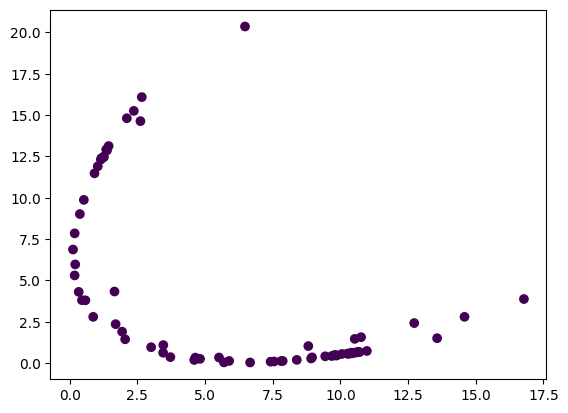

In [33]:
plt.scatter(euc_test_data[euc_gt==1, 0], euc_test_data[euc_gt==1, 1], c=euc_gt[euc_gt==1])

In [35]:
means= np.array([21.53148511, 16.47764607])
stds= np.array([19.88790257, 9.85630508])
test_x_norm = normalize_test_array(euc_test_data, True, means, stds, 'normalization_factors.pkl')
# test_x_norm2,  mean, std=std_normalize(euc_test_data, 'normalization_factors.pkl')
print(type(test_x_norm))
# print(test_x_norm.dtype)
# print(test_x_norm[:20, :])
test_tensor1 = torch.tensor(test_x_norm, dtype=torch.float32)
# test_tensor2 = torch.tensor(euc_test_data, dtype=torch.float32)

Ytest_tensor1 = torch.tensor(euc_gt, dtype=torch.float32).unsqueeze(1)

print(test_tensor1.shape)
print(Ytest_tensor1.shape)
test_dataset1 = TensorDataset(test_tensor1, Ytest_tensor1)
test_loader1 = DataLoader(test_dataset1, batch_size=32, shuffle=False)

positive_count = 0
negative_count = 0

for _, labels in test_loader1:
    positive_count += (labels == 1).sum().item()  
    negative_count += (labels == 0).sum().item() 

print(f"Positive examples in validation dataset: {positive_count}")
print(f"Negative examples in validation dataset: {negative_count}")


<class 'numpy.ndarray'>
torch.Size([187815, 2])
torch.Size([187815, 1])
Positive examples in validation dataset: 71
Negative examples in validation dataset: 187744


In [ ]:
model = model.to("cpu")
torch.save(model.state_dict(), "model_weights_2024-12-28_09-54-57_model_l3raxpq1_NqA9f.pth")

In [36]:
# to load in the future 
input_size = 2
output_size = 1
best_trial_params= {
"input_size":2,
"hidden_layer_1_neurons": 36,
"hidden_layer_2_neurons": 49,
"hidden_layer_3_neurons": 175,
"output_size": 1
}

# model_dict = joblib.load(f"nni/models/model_2tf9osk5_aquSV.joblib")
# print(model_dict)
model = MLP(**best_trial_params)
model_path = 'model_weights_2024-12-28_09-54-57_model_l3raxpq1_NqA9f.pth'
# print(model_path)
model_dict = torch.load(model_path)
# print(model_dict)
model.load_state_dict(model_dict)

/data/dust/user/boukela/beegfs.migration/tmp/ipykernel_1149040/510873524.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(model_path)


<All keys matched successfully>

In [47]:
model = model.to(device)
metrics, preds, all_labels = inference_on_test(model, test_loader1)
# print(f"final AUC: {metrics}")

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'tor

In [24]:
# euc_classifier1 = joblib.load(f"/home/boukela/GPFS/dust/maxwell/user/boukela/code/distance-NAS/nni/models/model_lcp8r6uf_A02E6.joblib")
# print(euc_classifier1)
all_labels=np.array(all_labels, dtype=int)
print(np.unique(all_labels))
print(preds[:10])
# euc_classifier1 = joblib.load(euc_model_path) 
# Test the model
# y_pred_euc_mlp = (euc_classifier1.predict(euc_test_data[:, 0:2]))
# y_pred_binary = np.argmax(y_pred, axis=1)
y_pred_euc_mlp=np.array(preds)
print(np.unique(np.array(y_pred_euc_mlp)))
# Y_test = keras.utils.to_categorical(test[:,4], 2)
# Evaluate the accuracy
f1_euc_mlp, t1_euc_mlp, th1=roc_curve(all_labels, y_pred_euc_mlp, pos_label=1)
auc_euc_mlp = auc(f1_euc_mlp, t1_euc_mlp)
print(f"auc={auc(f1_euc_mlp, t1_euc_mlp)}, TPR= {t1_euc_mlp}, FPR= {f1_euc_mlp}")
accuracy = accuracy_score(all_labels, y_pred_euc_mlp)
print(f"Accuracy on the test set: {accuracy}")
CM = confusion_matrix(all_labels, y_pred_euc_mlp)

TN_euc_mlp = CM[0][0]
FN_euc_mlp = CM[1][0]
TP_euc_mlp = CM[1][1]
FP_euc_mlp = CM[0][1]
print(FP_euc_mlp)    
clf_tpr=(TP_euc_mlp/(TP_euc_mlp+FN_euc_mlp))
clf_fpr=(FP_euc_mlp/(FP_euc_mlp+TN_euc_mlp)) 
print(f" TPR= {clf_tpr}")
print(f" FPR= {clf_fpr}")

[0 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0 1]
auc=0.9580728897845914, TPR= [0.         0.94366197 1.        ], FPR= [0.         0.02751619 1.        ]
Accuracy on the test set: 0.9724729121742139
5166
 TPR= 0.9436619718309859
 FPR= 0.027516192261803307


In [ ]:
# input_shape = (2,)
# flops, params = get_model_complexity_info(model, input_shape, as_strings=True, print_per_layer_stat=True)

def compute_objective(auc, flops, max_auc, max_flops, alpha=0.7, beta=0.3):

    input_shape = (input_size,)  

    with torch.cuda.device(0):
        flops, params = get_model_complexity_info(model, input_shape, as_strings=True, print_per_layer_stat=True)

    # print("FLOPs:", flops)
    # print("Parameters:", params)

    normalized_flops = flops / max_flops

    objective_value = alpha * auc - beta * normalized_flops
    return objective_value


input_shape = (2,)
flops, params = get_model_complexity_info(model, input_shape, as_strings=False, print_per_layer_stat=False)

print("FLOPs:", int(flops))
print("Parameters:", params)


FLOPs: 11367
Parameters: 10847


In [49]:
# import matplotlib.pyplot as plt
# import numpy as np


# EU_Accuracy_AUC = [0.929, 0.929, 44, 1, 17, 192] #KNN EUC
# DTW_Accuracy_AUC_adapt = [0.948, 0.948, 50, 2, 18, 175] #KNN DTW

# MLP_EUC_Accuracy_AUC = [0.910, 0.910, 48, 3, 16, 180]
# MLP_DTW_Accuracy_AUC = [0.910, 0.910, 48, 3, 16, 180]

# count_data = np.array([
#     [EU_Accuracy_AUC[2], EU_Accuracy_AUC[3], EU_Accuracy_AUC[4], EU_Accuracy_AUC[5]],
#     [DTW_Accuracy_AUC_adapt[2], DTW_Accuracy_AUC_adapt[3], DTW_Accuracy_AUC_adapt[4], DTW_Accuracy_AUC_adapt[5]],
#     [MLP_EUC_Accuracy_AUC[2], MLP_EUC_Accuracy_AUC[3], MLP_EUC_Accuracy_AUC[4], MLP_EUC_Accuracy_AUC[5]],
#     [MLP_DTW_Accuracy_AUC[2], MLP_DTW_Accuracy_AUC[3], MLP_DTW_Accuracy_AUC[4], MLP_DTW_Accuracy_AUC[5]]
# ])


# auc_data = [EU_Accuracy_AUC[1], DTW_Accuracy_AUC_adapt[1], MLP_EUC_Accuracy_AUC[1], MLP_DTW_Accuracy_AUC[1]]

# fig, ax1 = plt.subplots(figsize=(10, 7))
# x_labels = ["KNN_EUC", "KNN_DTW", "MLP_EUC", "MLP_DTW"]
# x = np.arange(len(x_labels))
# width = 0.2

# b1 = ax1.bar(x - width*1.5, count_data[:, 0], width, label='TP')
# b2 = ax1.bar(x - width*0.5, count_data[:, 1], width, label='FN')
# b3 = ax1.bar(x + width*0.5, count_data[:, 2], width, label='FP')
# b4 = ax1.bar(x + width*1.5, count_data[:, 3], width, label='TN')

# ax1.set_xlabel('Methods')
# ax1.set_ylabel('Number of Events')
# ax1.set_xticks(x)
# ax1.set_xticklabels(x_labels)
# ax1.legend(loc='upper left')

# def add_labels(bars):
#     for bar in bars:
#         yval = bar.get_height()
#         ax1.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

# add_labels(b1)
# add_labels(b2)
# add_labels(b3)
# add_labels(b4)

# ax2 = ax1.twinx()
# b5 = ax2.bar(x, auc_data, width=0.9, color='gray', alpha=0.2, edgecolor='black', label='AUC')

# ax2.set_ylabel('ROC-AUC')
# ax2.set_ylim(0, 1)

# for i, auc in enumerate(auc_data):
#     ax2.text(x[i], auc, f'{auc:.2f}', ha='center', va='bottom')

# plt.title('Evaluation Results')
# fig.tight_layout()
# # plt.show()

In [50]:
# import matplotlib.pyplot as plt
# import numpy as np

# EU_Accuracy_AUC = [0.929, 0.929, 44, 1, 17, 192]
# DTW_Accuracy_AUC_adapt = [0.948, 0.948, 50, 2, 18, 175]
# QDS_Accuracy_AUC = [0.910, 0.910, 48, 3, 16, 180]

# count_data = np.array([
#     [EU_Accuracy_AUC[2], EU_Accuracy_AUC[3], EU_Accuracy_AUC[4], EU_Accuracy_AUC[5]],
#     [DTW_Accuracy_AUC_adapt[2], DTW_Accuracy_AUC_adapt[3], DTW_Accuracy_AUC_adapt[4], DTW_Accuracy_AUC_adapt[5]],
#     [QDS_Accuracy_AUC[2], QDS_Accuracy_AUC[3], QDS_Accuracy_AUC[4], QDS_Accuracy_AUC[5]]
# ])

# max_count = count_data.max()
# normalized_count_data = count_data / max_count

# auc_data = [EU_Accuracy_AUC[1], DTW_Accuracy_AUC_adapt[1], QDS_Accuracy_AUC[1]]

# fig, ax1 = plt.subplots(figsize=(10, 7))
# x_labels = ["EUC", "DTW", "QDS"]
# x = np.arange(len(x_labels))
# width = 0.2

# b1 = ax1.bar(x - width*1.5, normalized_count_data[:, 0], width, label='TP')
# b2 = ax1.bar(x - width*0.5, normalized_count_data[:, 1], width, label='FN')
# b3 = ax1.bar(x + width*0.5, normalized_count_data[:, 2], width, label='FP')
# b4 = ax1.bar(x + width*1.5, normalized_count_data[:, 3], width, label='TN')

# ax1.set_ylabel('Normalized Event Counts')
# ax1.set_xticks(x)
# ax1.set_xticklabels(x_labels)
# ax1.legend(loc='upper left')

# for bars, original_data in zip([b1, b2, b3, b4], count_data.T):
#     for bar, orig_val in zip(bars, original_data):
#         ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(orig_val), ha='center', va='bottom')

# ax2 = ax1.twinx()
# b5 = ax2.bar(x, auc_data, width=0.5, color='gray', alpha=0.3, edgecolor='black', label='AUC')

# ax2.set_ylabel('ROC-AUC')
# ax2.set_ylim(0, 1)

# for i, auc in enumerate(auc_data):
#     ax2.text(x[i], auc, f'{auc:.2f}', ha='center', va='bottom', color='black')

# plt.title('Evaluation Results with Normalized Counts and AUC')
# fig.tight_layout()
# plt.show()
